In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
df = pd.read_csv("car data.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df.shape

(4340, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [5]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [6]:
df.duplicated().sum()

np.int64(763)

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(3577, 8)

In [10]:
print(df["fuel"].unique())
print(df["seller_type"].unique())
print(df["transmission"].unique())
print(df["owner"].unique())

<StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str
<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
<StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str


In [11]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [12]:
df["brand"] = df["name"].str.split().str[0]
df["brand"].value_counts().head(15)

brand
Maruti        1072
Hyundai        637
Mahindra       328
Tata           308
Ford           220
Honda          216
Toyota         170
Chevrolet      151
Renault        110
Volkswagen      93
Nissan          52
Skoda           49
Fiat            32
Audi            31
Datsun          29
Name: count, dtype: int64

In [13]:
df["car_age"] = 2026 - df["year"]
df[["year", "car_age"]].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [14]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
brand            0
car_age          0
dtype: int64

In [15]:
df["brand"] = df["name"].str.split().str[0]

df["brand"].value_counts().head(15)

brand
Maruti        1072
Hyundai        637
Mahindra       328
Tata           308
Ford           220
Honda          216
Toyota         170
Chevrolet      151
Renault        110
Volkswagen      93
Nissan          52
Skoda           49
Fiat            32
Audi            31
Datsun          29
Name: count, dtype: int64

In [17]:
print("Number of unique brands:", df["brand"].nunique())
print(df["brand"].unique())

Number of unique brands: 29
['Maruti' 'Hyundai' 'Datsun' 'Honda' 'Tata' 'Chevrolet' 'Toyota' 'Jaguar'
 'Mercedes-Benz' 'Audi' 'Skoda' 'Jeep' 'BMW' 'Mahindra' 'Ford' 'Nissan'
 'Renault' 'Fiat' 'Volkswagen' 'Volvo' 'Mitsubishi' 'Land' 'Daewoo' 'MG'
 'Force' 'Isuzu' 'OpelCorsa' 'Ambassador' 'Kia']


In [18]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12


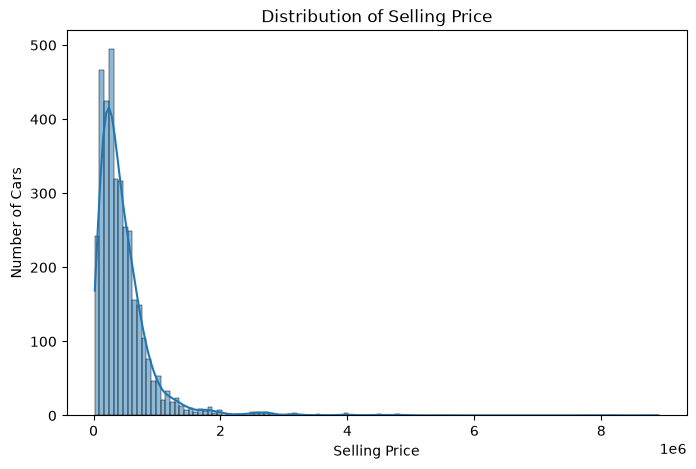

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["selling_price"], kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

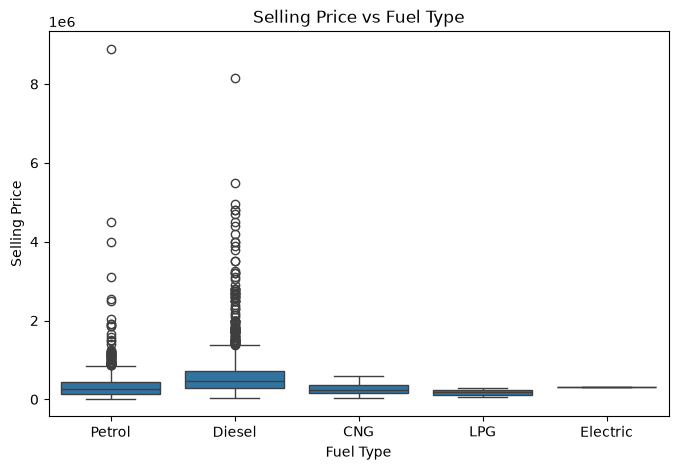

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x="fuel", y="selling_price", data=df)

plt.title("Selling Price vs Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

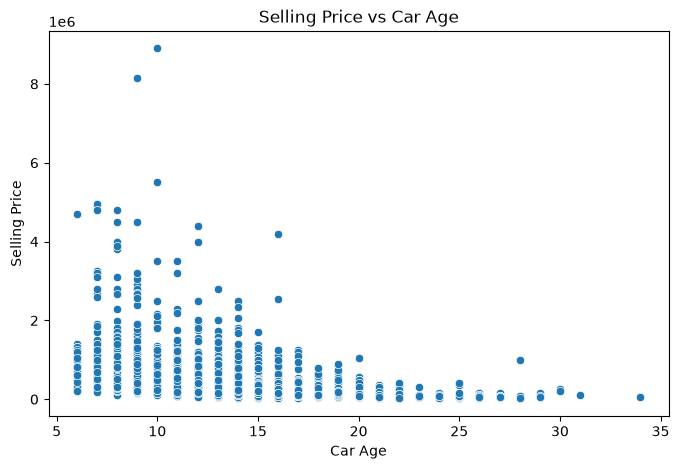

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="car_age",
    y="selling_price",
    data=df
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

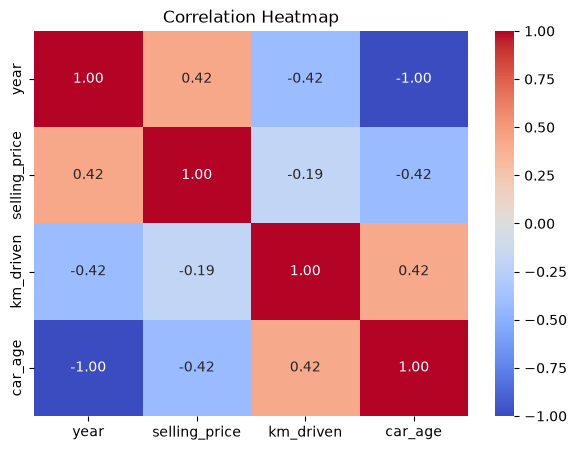

In [22]:
corr_data = df[["year", "selling_price", "km_driven", "car_age"]]

plt.figure(figsize=(7,5))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [23]:
df_model = df.drop(["name", "year"], axis=1)

df_model.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12


In [24]:
df_model = pd.get_dummies(
    df_model,
    columns=[
        "brand",
        "fuel",
        "seller_type",
        "transmission",
        "owner"
    ],
    drop_first=True,
    dtype=int
)

df_model.head()

,selling_price,km_driven,car_age,brand_Audi,brand_BMW,brand_Chevrolet,brand_Daewoo,brand_Datsun,brand_Fiat,brand_Force,...,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,19,0,0,0,0,0,0,0,...,0,0,1,1,0,1,0,0,0,0
1,135000,50000,19,0,0,0,0,0,0,0,...,0,0,1,1,0,1,0,0,0,0
2,600000,100000,14,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
3,250000,46000,9,0,0,0,0,1,0,0,...,0,0,1,1,0,1,0,0,0,0
4,450000,141000,12,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,1,0,0


In [25]:
print("Dataset shape:", df_model.shape)
print("Missing values:", df_model.isnull().sum().sum())

Dataset shape: (3577, 42)
Missing values: 0


In [26]:
X = df_model.drop("selling_price", axis=1)

y = df_model["selling_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3577, 41)
y shape: (3577,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2861, 41)
Testing data: (716, 41)


In [28]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
-------------------------
MAE : 185413.7601837149
RMSE: 380273.3547253721
R²  : 0.5510932901086285


In [32]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
-------------------------
MAE : 158662.94340468
RMSE: 364619.51314395474
R²  : 0.587290829996777


In [33]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2 Score": [
        r2_lr,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,185413.760184,380273.354725,0.551093
1,Random Forest,158662.943405,364619.513144,0.587291


In [34]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15)

transmission_Manual       0.244025
car_age                   0.225570
km_driven                 0.136444
fuel_Diesel               0.074623
brand_Audi                0.052550
brand_Land                0.040341
fuel_Petrol               0.038666
brand_Toyota              0.037374
seller_type_Individual    0.019335
brand_BMW                 0.014321
brand_Mercedes-Benz       0.010543
brand_Maruti              0.010283
brand_Jaguar              0.010155
brand_Mahindra            0.009324
owner_Second Owner        0.008166
dtype: float64

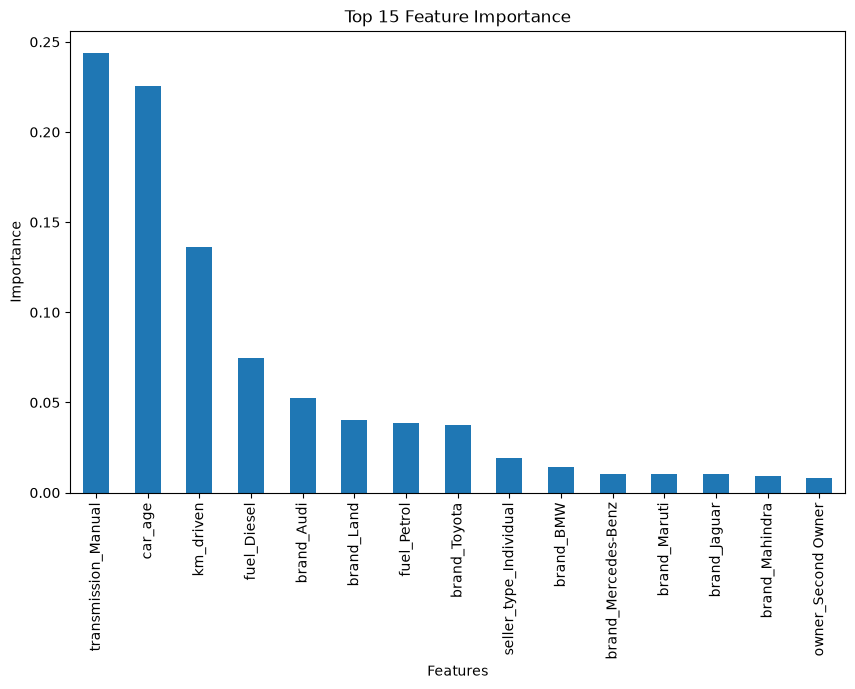

In [35]:
plt.figure(figsize=(10,6))

importance.head(15).plot(kind="bar")

plt.title("Top 15 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

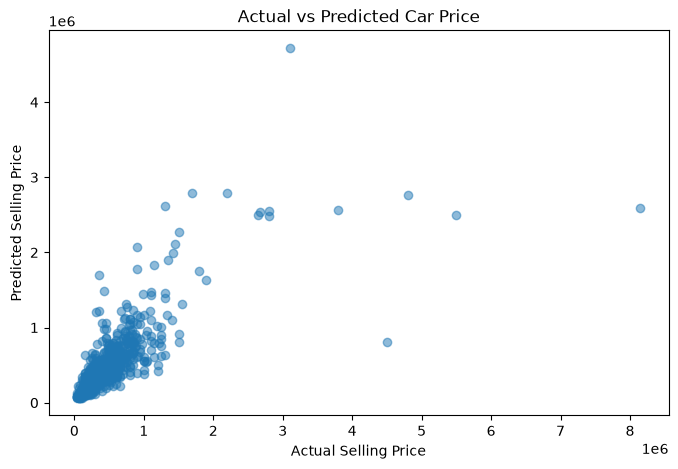

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Price")

plt.show()

In [38]:
print("Final number of rows:", len(df))
print("Final number of features:", X.shape[1])
print("Final model dataset shape:", df_model.shape)

Final number of rows: 3577
Final number of features: 41
Final model dataset shape: (3577, 42)


## Conclusion

In this project, a machine learning model was developed to predict used car selling prices.

The dataset was cleaned by removing duplicate records and checking missing values.

Car age and brand were created as new features.

Exploratory Data Analysis was performed using different visualizations.

Categorical features were converted into numerical form using one-hot encoding.

Two regression models were trained:
1. Linear Regression
2. Random Forest Regression

The models were evaluated using MAE, RMSE, and R² score.

Feature importance was also analyzed to understand the important factors affecting car prices.